In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

In [4]:
data = np.array([1,2,np.nan,4,5,np.nan,7,8,9,10], dtype=float)

data

array([ 1.,  2., nan,  4.,  5., nan,  7.,  8.,  9., 10.])

In [5]:
interp_data = pd.Series(data).interpolate(method='linear')

interp_data

0     1.0
1     2.0
2     3.0
3     4.0
4     5.0
5     6.0
6     7.0
7     8.0
8     9.0
9    10.0
dtype: float64

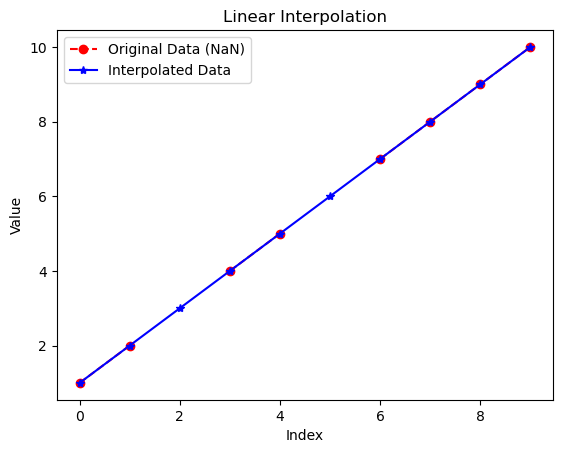

In [6]:
plt.figure()

plt.plot(data, 'ro--', label="Original Data (NaN)")
plt.plot(interp_data, 'b*-', label="Interpolated Data")

plt.legend()
plt.title("Linear Interpolation")
plt.xlabel("Index")
plt.ylabel("Value")

plt.show()

In [7]:
data_knn = data.reshape(-1,1)

In [8]:
imputer = KNNImputer(n_neighbors=3)

knn_data = imputer.fit_transform(data_knn)

knn_data = knn_data.flatten()

knn_data

array([ 1.  ,  2.  ,  5.75,  4.  ,  5.  ,  5.75,  7.  ,  8.  ,  9.  ,
       10.  ])

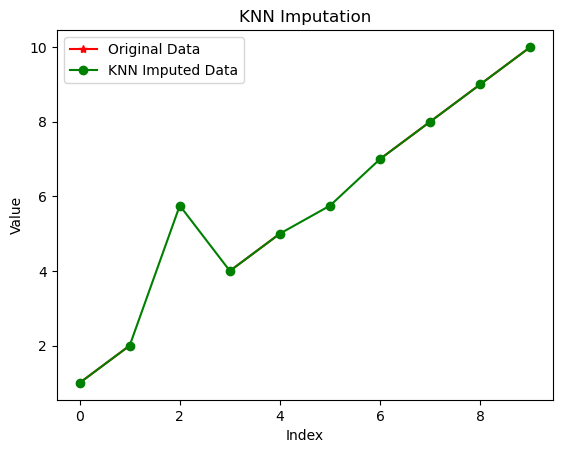

In [9]:
plt.figure()

plt.plot(data, 'r*-', label="Original Data")
plt.plot(knn_data, 'go-', label="KNN Imputed Data")

plt.legend()
plt.title("KNN Imputation")
plt.xlabel("Index")
plt.ylabel("Value")

plt.show()

In [10]:
X = np.arange(1,11).reshape(-1,1)
Y = data.copy()

In [11]:
known_mask = ~np.isnan(Y)

X_known = X[known_mask]
Y_known = Y[known_mask]

In [12]:
model = LinearRegression()
model.fit(X_known, Y_known)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
reg_data = Y.copy()

missing_mask = np.isnan(Y)

reg_data[missing_mask] = model.predict(X[missing_mask])

reg_data

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

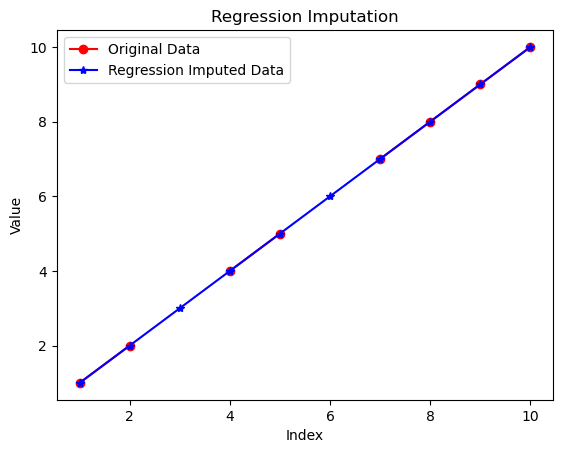

In [14]:
plt.figure()

plt.plot(X, Y, 'ro-', label="Original Data")
plt.plot(X, reg_data, 'b*-', label="Regression Imputed Data")

plt.legend()
plt.title("Regression Imputation")
plt.xlabel("Index")
plt.ylabel("Value")

plt.show()